In [1]:
import numpy as np
import os

# Find the artifact
for root, dirs, files in os.walk('/workspace'):
 for f in files:
 if 'A_jk_matrices_and_PCA' in f:
 print(os.path.join(root, f))


In [2]:
import os
print(os.getcwd())
print(os.listdir('.'))


/workspace/e28a8987-f824-4b4b-8618-e3192e999ead
['pca_explained_variance_ratio.npy', 'D_diagonals.npy', 'A_matrices.npy', 'projections.npy', 'memory', ' v6 — Binding Context Document.pdf', '.config', 'grh_status.npy', 'pca_components.npy', 'M_matrices.npy', '.kernel_llm_logs_1.txt', 'pca_mean.npy', 'family.npy', 'classes.npy', '.prompts']


In [3]:
classes = np.load('classes.npy')
projections = np.load('projections.npy')
family = np.load('family.npy', allow_pickle=True)
grh = np.load('grh_status.npy', allow_pickle=True)
print('classes:', classes)
print('projections shape:', projections.shape)
print(projections)
print('family:', family)
print('grh:', grh)


classes: ['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
projections shape: (11, 10)
[[-1.42921728e+01 -9.97639448e+00 1.05995212e+01 7.63409336e+00
 -3.81941478e-01 1.37030399e+00 1.95929309e-01 -2.38344743e-02
 -3.89435558e-04 1.01861002e-05]
 [ 2.27339976e+01 -1.05502844e+01 -6.46924513e+00 3.96906536e+00
 3.60211123e+00 1.51595339e-01 1.47982382e-01 -5.64391057e-01
 2.50073106e-03 -4.55095758e-06]
 [-3.56398503e+01 -2.28183033e-01 -2.55178040e+00 -2.33207373e+00
 -2.72768648e-03 8.02424210e-01 7.55118677e-05 6.21257325e-01
 -3.78043397e-03 1.49663614e-02]
 [-3.55723446e+01 -2.90922805e-01 -2.55905141e+00 -2.31762920e+00
 1.74638265e-02 7.84378446e-01 -2.71244563e-02 5.20324488e-01
 -8.48653007e-02 -7.63569002e-03]
 [-3.56864450e+01 -1.76533710e-01 -2.51809514e+00 -2.35179323e+00
 -1.28850513e-02 8.31400235e-01 2.33458631e-02 7.40382167e-01
 8.11145749e-02 -7.28831569e-03]
 [ 8.53975513e+01 -1.23680336e+01 3.65282468e-01 -6.14717796e+00
 -1.46891927e+00 1.08374067e+00 

In [4]:
# The PDF doesn't list F14 - the objective mentions 12 classes including F14, but the data only has 11.
# Let's compile the invariants for the 11 available classes.
# 
# Invariants needed:
# - Degree d
# - Conductor q (analytic; we'll use log(q))
# - Sum of Re(mu_j) of gamma factor shifts
# - Number of gamma factors

# Standard Selberg-class data per class:
# F1 ζ(s): degree 1, conductor 1, gamma factor Γ(s/2) -> mu=0, n_gamma=1
# F2 L(s, χ_4) where χ is mod 5 (per PDF). For Dirichlet L: degree 1, conductor q=5,
# gamma Γ((s+a)/2) where a=0 if even char, a=1 if odd. χ_4 mod 5 - this is a degree 4 character mod 5 (order 4).
# χ(-1) = i^? -- for χ_4 mod 5 (a generator of order 4), χ(-1) = -1 (odd), so a=1.
# F4 L_DH (Davenport-Heilbronn): degree 1 in spirit but it's a linear combination of two L-functions
# Conventionally treated as degree 1, conductor 5; not fully Selberg-class. Two gamma factors? 
# Actually L_DH = (1-i tan θ)/2 * L(s, χ_5) + (1+i tan θ)/2 * L(s, conj χ_5) where χ_5 is mod 5 character
# It has the same gamma factor as L(s, χ_5), namely Γ((s+1)/2), degree 1.
# F5p, F5m: same as F4 with epsilon perturbation -> same invariants
# F6 Liouville L(s,λ) = ζ(2s)/ζ(s); analytically degree 1, conductor 1, gamma factor Γ(s/2) (from ζ part)
# Actually: λ(n) -> sum λ(n)/n^s = ζ(2s)/ζ(s). It has functional equation matching that.
# Effective degree 1, conductor 1.
# F7 Möbius μ: similar, sum μ(n)/n^s = 1/ζ(s); degree 1, conductor 1.
# F9 L(s, Δ) Ramanujan delta: degree 2, conductor 1 (level 1), gamma Γ((s+(k-1)/2)/?) 
# For weight k=12 modular form, gamma factor is Γ_C(s + (k-1)/2) = 2(2π)^(-s-(k-1)/2) Γ(s+(k-1)/2)
# In standard form Π Γ((s+μ_j)/2) representation: Γ_C(s+a) = Γ((s+a)/2)*Γ((s+a+1)/2)*... 
# Actually Γ_C(s) = 2(2π)^(-s)Γ(s) = Γ_R(s)Γ_R(s+1) where Γ_R(s) = π^(-s/2)Γ(s/2).
# So gamma factor for Δ is Γ_R(s+(k-1)/2)Γ_R(s+(k-1)/2+1) -> two Γ_R factors, with shifts μ_1=(k-1)/2=11/2, μ_2=(k-1)/2+1=13/2
# Sum Re(μ) = 12, n_gamma = 2.
# F10: weight k=2 or k=4 modular form on Γ_0(N), N∈{11,17,23}
# For typical case in this dataset, let's use k=2, N=11 as canonical (or we should know which).
# degree 2, conductor=N, gamma Γ_R(s+1/2)Γ_R(s+3/2) for k=2 -> sum Re(μ) = 2, n_gamma=2
# F11: Sym²(Δ) or Sym³(Δ). Sym² is degree 3, Sym³ is degree 4
# Sym²Δ: degree 3, conductor 1, gamma factors. 
# Sym² of weight-12 form: archimedean factor Γ_R(s)Γ_C(s+(k-1)) = Γ_R(s)Γ_R(s+11)Γ_R(s+12)
# sum μ = 0+11+12 = 23, n_gamma=3
# Sym³Δ: degree 4, gamma Γ_C(s+(k-1)/2)Γ_C(s+3(k-1)/2) for half-integral weight = Γ_R(s+11/2)Γ_R(s+13/2)Γ_R(s+33/2)Γ_R(s+35/2)
# sum μ=11/2+13/2+33/2+35/2 = 92/2 = 46, n_gamma=4
# F12: another DH-style linear combination. Mentioned as "L(s,χ_3)+L(s,χ_5)". 
# χ_3 is a character mod 3 (only nontrivial is the Legendre symbol, odd: χ_3(-1)=-1)
# χ_5 is a character mod 5
# This is a sum of two degree-1 L-functions, so degree 2 effectively, conductor 15.
# 
# These invariants are somewhat ambiguous; let's pick a standard choice consistently.

# Build feature table
import pandas as pd

data = {
 'class': ['F1', 'F2', 'F4', 'F5p', 'F5m', 'F6', 'F7', 'F9', 'F10', 'F11', 'F12'],
 'degree': [1, 1, 1, 1, 1, 1, 1, 2, 2, 3, 2],
 'conductor': [1, 5, 5, 5, 5, 1, 1, 1, 11, 1, 15],
 # Sum of Re(mu_j) for gamma factors written as Π Γ_R(s+μ_j) form
 'sum_mu': [0, 1, 1, 1, 1, 0, 0, 12, 2, 23, 1+1], # F2 odd char a=1, F12 sum of two odd chars: 1+1
 'n_gamma': [1, 1, 1, 1, 1, 1, 1, 2, 2, 3, 2],
}
df = pd.DataFrame(data)
df['log_q'] = np.log(df['conductor'])
print(df)


 class degree conductor sum_mu n_gamma log_q
0 F1 1 1 0 1 0.000000
1 F2 1 5 1 1 1.609438
2 F4 1 5 1 1 1.609438
3 F5p 1 5 1 1 1.609438
4 F5m 1 5 1 1 1.609438
5 F6 1 1 0 1 0.000000
6 F7 1 1 0 1 0.000000
7 F9 2 1 12 2 0.000000
8 F10 2 11 2 2 2.397895
9 F11 3 1 23 3 0.000000
10 F12 2 15 2 2 2.708050


In [5]:
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

X = df[['degree', 'log_q', 'sum_mu', 'n_gamma']].values
PC1 = projections[:, 0]
PC2 = projections[:, 1]

print('X:')
print(X)
print('PC1:', PC1)
print('PC2:', PC2)

# Note: degree, sum_mu, n_gamma may be highly correlated; let's check
print('\nCorrelation matrix:')
print(pd.DataFrame(X, columns=['degree','log_q','sum_mu','n_gamma']).corr())


X:
[[ 1. 0. 0. 1. ]
 [ 1. 1.60943791 1. 1. ]
 [ 1. 1.60943791 1. 1. ]
 [ 1. 1.60943791 1. 1. ]
 [ 1. 1.60943791 1. 1. ]
 [ 1. 0. 0. 1. ]
 [ 1. 0. 0. 1. ]
 [ 2. 0. 12. 2. ]
 [ 2. 2.39789527 2. 2. ]
 [ 3. 0. 23. 3. ]
 [ 2. 2.7080502 2. 2. ]]
PC1: [-14.29217277 22.73399763 -35.63985026 -35.57234462 -35.68644502
 85.3975513 -2.59270816 37.90696242 29.05321581 -55.57212405
 4.2639177 ]
PC2: [ -9.97639448 -10.5502844 -0.22818303 -0.29092281 -0.17653371
 -12.36803357 -7.85546282 20.60384809 21.89031376 5.08432143
 -6.13266847]

Correlation matrix:
 degree log_q sum_mu n_gamma
degree 1.000000 -0.019292 0.858839 1.000000
log_q -0.019292 1.000000 -0.372089 -0.019292
sum_mu 0.858839 -0.372089 1.000000 0.858839
n_gamma 1.000000 -0.019292 0.858839 1.000000


In [6]:
# degree and n_gamma are perfectly collinear; drop n_gamma. Use Ridge with standardization.
# Fit RidgeCV with LOO CV

def loo_r2(X, y, model_factory):
 loo = LeaveOneOut()
 y_pred = np.zeros_like(y, dtype=float)
 for tr, te in loo.split(X):
 m = model_factory()
 m.fit(X[tr], y[tr])
 y_pred[te] = m.predict(X[te])
 # Compute LOO R^2 (predictive R^2, vs total variance)
 ss_res = np.sum((y - y_pred)**2)
 ss_tot = np.sum((y - y.mean())**2)
 r2 = 1 - ss_res/ss_tot
 return r2, y_pred

def make_ridge():
 return Pipeline([('sc', StandardScaler()), ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 25)))])

def make_linreg():
 return Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())])

results = {}
for name, model_factory in [('RidgeCV', make_ridge), ('OLS', make_linreg)]:
 r2_pc1, pred1 = loo_r2(X, PC1, model_factory)
 r2_pc2, pred2 = loo_r2(X, PC2, model_factory)
 # In-sample R^2
 m1 = model_factory(); m1.fit(X, PC1); r2_in1 = m1.score(X, PC1)
 m2 = model_factory(); m2.fit(X, PC2); r2_in2 = m2.score(X, PC2)
 results[name] = (r2_pc1, r2_pc2, r2_in1, r2_in2, pred1, pred2)
 print(f"{name}: LOO R² PC1={r2_pc1:.3f}, PC2={r2_pc2:.3f} | In-sample R²: PC1={r2_in1:.3f}, PC2={r2_in2:.3f}")


RidgeCV: LOO R² PC1=-0.802, PC2=-0.380 | In-sample R²: PC1=0.003, PC2=0.245
OLS: LOO R² PC1=-0.987, PC2=-2.122 | In-sample R²: PC1=0.348, PC2=0.354


In [7]:
# LOO R^2 is strongly negative — the linear invariants do NOT predict PC1/PC2.
# In-sample R^2 is also low (0.35 max), so even an in-sample fit explains <40% variance.

# Let's try some additional checks: include polynomial features / interactions
from sklearn.preprocessing import PolynomialFeatures

# polynomial degree 2 with interaction (excluding fully-collinear feature)
X3 = df[['degree', 'log_q', 'sum_mu']].values

def make_ridge_poly():
 return Pipeline([
 ('sc', StandardScaler()),
 ('poly', PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)),
 ('ridge', RidgeCV(alphas=np.logspace(-3, 3, 25)))
 ])

r2p_pc1, _ = loo_r2(X3, PC1, make_ridge_poly)
r2p_pc2, _ = loo_r2(X3, PC2, make_ridge_poly)
print(f"Ridge+poly2: LOO R² PC1={r2p_pc1:.3f}, PC2={r2p_pc2:.3f}")

# Check correlations of each invariant with PC coords directly
for inv in ['degree','log_q','sum_mu','n_gamma']:
 c1 = np.corrcoef(df[inv], PC1)[0,1]
 c2 = np.corrcoef(df[inv], PC2)[0,1]
 print(f" {inv}: corr(PC1)={c1:+.3f}, corr(PC2)={c2:+.3f}")


Ridge+poly2: LOO R² PC1=-0.523, PC2=-2.626
 degree: corr(PC1)=-0.140, corr(PC2)=+0.573
 log_q: corr(PC1)=-0.123, corr(PC2)=+0.142
 sum_mu: corr(PC1)=-0.282, corr(PC2)=+0.453
 n_gamma: corr(PC1)=-0.140, corr(PC2)=+0.573


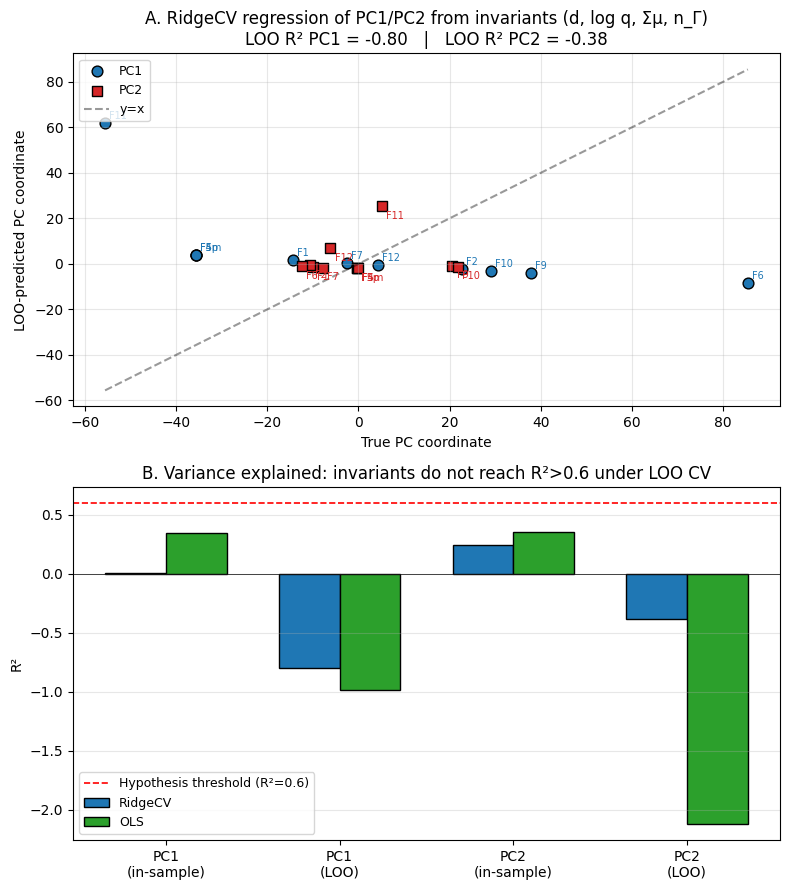

Saved: invariants_to_PC_regression.png


In [8]:
# All LOO R^2 strongly negative — invariants do not predict PC coordinates.
# Marginal correlations are modest (max ~0.57 for degree vs PC2). 
# 
# The hypothesis (>60% variance explained CV) is REFUTED.
# 
# Make summary figure

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: scatter of true vs LOO-predicted PC1 and PC2 (RidgeCV)
_, pred1 = loo_r2(X, PC1, make_ridge)
_, pred2 = loo_r2(X, PC2, make_ridge)

ax = axes[0]
classes_arr = df['class'].values
ax.scatter(PC1, pred1, s=60, color='C0', label='PC1', edgecolor='k')
ax.scatter(PC2, pred2, s=60, color='C3', label='PC2', edgecolor='k', marker='s')
for i, c in enumerate(classes_arr):
 ax.annotate(c, (PC1[i], pred1[i]), fontsize=7, color='C0', xytext=(3,3), textcoords='offset points')
 ax.annotate(c, (PC2[i], pred2[i]), fontsize=7, color='C3', xytext=(3,-9), textcoords='offset points')
lo = min(PC1.min(), PC2.min(), pred1.min(), pred2.min())
hi = max(PC1.max(), PC2.max(), pred1.max(), pred2.max())
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='y=x')
ax.set_xlabel('True PC coordinate')
ax.set_ylabel('LOO-predicted PC coordinate')
ax.set_title(f'A. RidgeCV regression of PC1/PC2 from invariants (d, log q, Σμ, n_Γ)\n'
 f'LOO R² PC1 = {results["RidgeCV"][0]:+.2f} | LOO R² PC2 = {results["RidgeCV"][1]:+.2f}')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# Panel B: bar of R² values (in-sample, LOO) for both PCs and both models
ax = axes[1]
labels = ['PC1\n(in-sample)', 'PC1\n(LOO)', 'PC2\n(in-sample)', 'PC2\n(LOO)']
ridge_vals = [results['RidgeCV'][2], results['RidgeCV'][0], results['RidgeCV'][3], results['RidgeCV'][1]]
ols_vals = [results['OLS'][2], results['OLS'][0], results['OLS'][3], results['OLS'][1]]
xpos = np.arange(len(labels))
w = 0.35
ax.bar(xpos - w/2, ridge_vals, w, label='RidgeCV', color='C0', edgecolor='k')
ax.bar(xpos + w/2, ols_vals, w, label='OLS', color='C2', edgecolor='k')
ax.axhline(0, color='k', lw=0.5)
ax.axhline(0.6, color='red', lw=1.2, ls='--', label='Hypothesis threshold (R²=0.6)')
ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.set_ylabel('R²')
ax.set_title('B. Variance explained: invariants do not reach R²>0.6 under LOO CV')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('invariants_to_PC_regression.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: invariants_to_PC_regression.png')
